# AI Wildlife Detection

## Exploratory Data Analysis

In [1]:
import requests

url = "https://lilawildlife.blob.core.windows.net/lila-wildlife/oregon-critters/oregon_critters.zip"

with requests.get(url, stream=True) as r:
    with open("oregon.zip", "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

In [2]:
import zipfile

zf = zipfile.ZipFile("oregon.zip")
zf.namelist()[:20]  # preview contents

['oregon_critters.json']

In [3]:
import zipfile
import json

with zipfile.ZipFile("oregon.zip", "r") as zf:
    with zf.open("oregon_critters.json") as f:
        data = json.load(f)

type(data)

dict

In [4]:
if isinstance(data, dict):
    print(data.keys())
elif isinstance(data, list):
    print("Top level is a list")
    print("Length:", len(data))
    print("First item keys:", data[0].keys() if len(data) > 0 and isinstance(data[0], dict) else type(data[0]))

dict_keys(['info', 'images', 'annotations', 'categories'])


In [5]:
for k, v in data.items():
    if isinstance(v, list):
        print(k, len(v))

images 99909
annotations 102014
categories 46


In [6]:
# print cats
cat_ids = {c["id"]: c["name"] for c in data["categories"]}
print("Categories:")
for cat_id, cat_name in cat_ids.items():
    print(f"{cat_id}: {cat_name}")

Categories:
0: empty
1: coyote
2: bat species
3: strigidae family
4: ruffed grouse
5: red fox
6: canada jay
7: pileated woodpecker
8: reptile or amphibian
9: bobcat
10: marten
11: california ground squirrel
12: mink
13: western spotted skunk
14: mountain beaver
15: black bear
16: black-tailed deer
17: cougar
18: roosevelt elk
19: stellers jay
20: catharus species
21: varied thrush
22: dark-eyed junco
23: american robin
24: leporidae family
25: douglas squirrel
26: humboldt's flying squirrel
27: townsend's chipmunk
28: weasel family
29: parulidae family
30: invertebrate
31: picidae family
32: neotoma species
33: poecile species
34: virginia opossum
35: troglodytidae family
36: mountain quail
37: northern raccoon
38: striped skunk
39: western gray squirrel
40: northern flicker
41: domestic dog
42: human
43: small mammal
44: gray fox
45: other bird


In [7]:
target_class_ids = {
    0, # empty
    1, 8, 11, 13, 23, 24, 30, 37, 38, 41, 42, 43, 44, 45
}

In [8]:
filtered_annotations = [
    ann for ann in data["annotations"]
    if ann["category_id"] in target_class_ids
]

print("Annotations kept:", len(filtered_annotations))

Annotations kept: 28001


In [9]:
image_ids = {ann["image_id"] for ann in filtered_annotations}

print("Unique images:", len(image_ids))

Unique images: 27646


In [10]:
filtered_images = [
    img for img in data["images"]
    if img["id"] in image_ids
]

print("Images kept:", len(filtered_images))

Images kept: 27646


In [11]:
filtered_categories = [
    cat for cat in data["categories"]
    if cat["id"] in target_class_ids
]

In [12]:
subset_data = {
    "images": filtered_images,
    "annotations": filtered_annotations,
    "categories": filtered_categories
}

In [13]:
import json

with open("oregon_filtered.json", "w") as f:
    json.dump(subset_data, f)

print("Saved filtered dataset")

Saved filtered dataset


In [14]:
print(filtered_images[0])

{'location': 'COA_NA', 'datetime': '2019-08-15 14:11:33', 'split': 'train', 'width': 3840, 'height': 2880, 'file_name': 'COA_2019/COA_2019_empty/images/10022-1__2019-08-15__14-11-33(1).JPG', 'id': 'COA_2019/COA_2019_empty/images/10022-1__2019-08-15__14-11-33(1).JPG', 'sequence_level_annotation': False}


In [15]:
import os
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

base_url = "https://lilawildlife.blob.core.windows.net/lila-wildlife/oregon-critters/"
out_dir = "images_subset"
os.makedirs(out_dir, exist_ok=True)

session = requests.Session()

def download_one(img):
    url = base_url + img["file_name"]
    path = os.path.join(out_dir, img["file_name"])
    tmp_path = path + ".part"

    if os.path.exists(path):
        return True, img["file_name"], "skipped"

    os.makedirs(os.path.dirname(path), exist_ok=True)

    try:
        r = session.get(url, timeout=20, stream=True)
        r.raise_for_status()

        with open(tmp_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

        os.replace(tmp_path, path)
        return True, img["file_name"], None

    except Exception as e:
        if os.path.exists(tmp_path):
            os.remove(tmp_path)
        return False, img["file_name"], str(e)

max_workers = 16

to_download = [
    img for img in filtered_images
    if not os.path.exists(os.path.join(out_dir, img["file_name"]))
]

results_ok = 0
results_fail = 0
results_skip = len(filtered_images) - len(to_download)

with ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = [ex.submit(download_one, img) for img in to_download]

    with tqdm(total=len(filtered_images), desc="Downloading", unit="img") as pbar:
        pbar.update(results_skip)
        pbar.set_postfix(ok=results_ok, fail=results_fail, skip=results_skip)

        for fut in as_completed(futures):
            ok, name, err = fut.result()
            if ok:
                results_ok += 1
            else:
                results_fail += 1

            pbar.set_postfix(ok=results_ok, fail=results_fail, skip=results_skip)
            pbar.update(1)

print("Done:", results_ok, "ok,", results_fail, "failed,", results_skip, "skipped")

Downloading: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 27646/27646 [00:26<00:00, 1027.97img/s, fail=275, ok=0, skip=27371] 

Done: 0 ok, 275 failed, 27371 skipped


missing values

In [16]:
import json, os

# Keep only images whose file exists on disk
valid_images = [
    img for img in filtered_images
    if os.path.exists(os.path.join(out_dir, img["file_name"]))
]

valid_ids = {img["id"] for img in valid_images}

valid_annotations = [
    ann for ann in filtered_annotations
    if ann["image_id"] in valid_ids
]

print(f"Images  before: {len(filtered_images):>6}  after: {len(valid_images):>6}  removed: {len(filtered_images) - len(valid_images)}")
print(f"Annotations     before: {len(filtered_annotations):>6}  after: {len(valid_annotations):>6}  removed: {len(filtered_annotations) - len(valid_annotations)}")

# Overwrite the JSON with the cleaned subset
subset_data_clean = {
    "images": valid_images,
    "annotations": valid_annotations,
    "categories": filtered_categories,
}

with open("oregon_filtered.json", "w") as f:
    json.dump(subset_data_clean, f)

# Update in-memory references so downstream cells stay consistent
filtered_images[:] = valid_images
filtered_annotations[:] = valid_annotations

print("oregon_filtered.json updated - missing-image rows removed.")

Images  before:  27646  after:  27371  removed: 275
Annotations     before:  28001  after:  27639  removed: 362
oregon_filtered.json updated - missing-image rows removed.


In [17]:
from PIL import Image
import os, random

sample_images = random.sample(filtered_images, min(1000, len(filtered_images)))

unique_dims = set()

for img in sample_images:
    path = os.path.join(out_dir, img["file_name"])

    if os.path.exists(path):
        try:
            with Image.open(path) as im:
                unique_dims.add(im.size)  # (width, height)
        except Exception:
            pass

# print distinct dimensions
for w, h in sorted(unique_dims):
    print(f"{w}x{h}")

print("Total distinct sizes:", len(unique_dims))

1920x1080
1920x1440
2048x1152
2048x1440
2048x1536
3264x2448
3776x2124
3840x2160
3840x2880
4000x3000
5280x3960
Total distinct sizes: 11


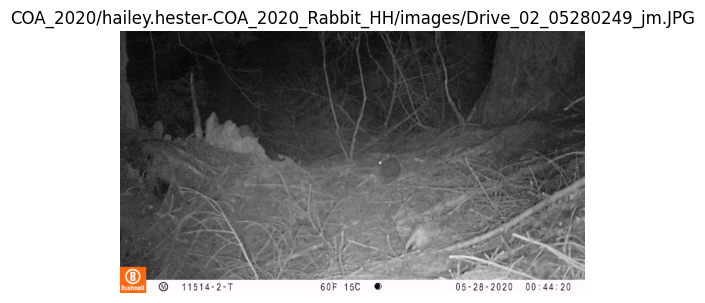

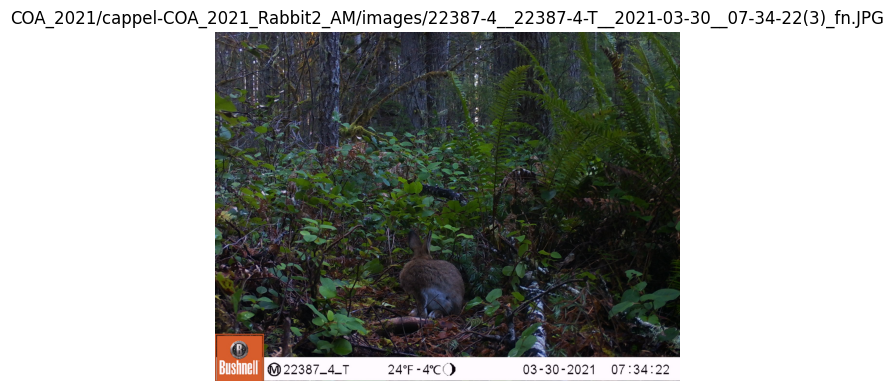

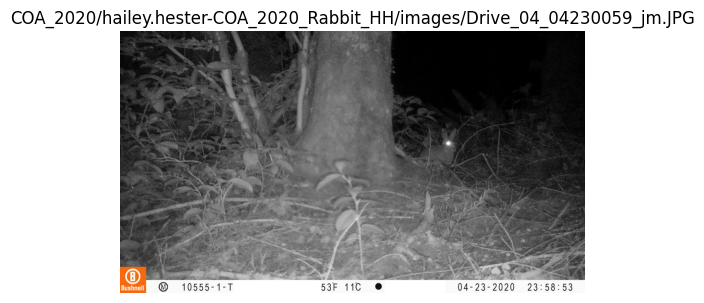

In [18]:
from PIL import Image
import matplotlib.pyplot as plt
import random, os

sample_images = random.sample(filtered_images, min(3, len(filtered_images)))

for img in sample_images:
    path = os.path.join(out_dir, img["file_name"])

    if os.path.exists(path):
        try:
            im = Image.open(path)
            plt.figure(figsize=(6, 6))
            plt.imshow(im)
            plt.title(img["file_name"])
            plt.axis("off")
            plt.show()
        except Exception as e:
            print(f"Error loading {img['file_name']}: {e}")
    else:
        print(f"Missing: {img['file_name']}")

## Preprocessing

In [19]:
import torchvision.transforms as transforms
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((0, 0, img.width, int(img.height * 0.94)))), # remove footer
    transforms.Resize(320),
    transforms.RandomCrop(288),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((0, 0, img.width, int(img.height * 0.94)))), # remove footer
    transforms.Resize(320),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

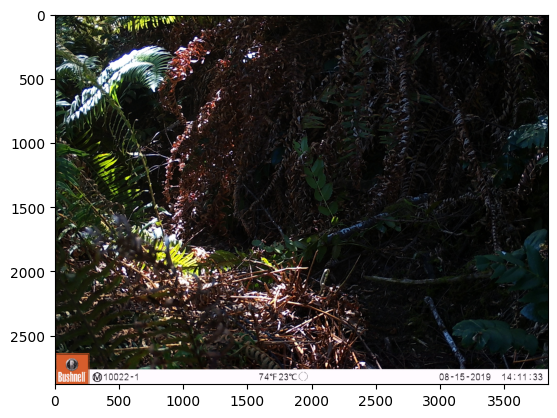

In [20]:
img0 = Image.open(os.path.join(out_dir, filtered_images[0]["file_name"]))
plt.imshow(img0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..1.2456646].


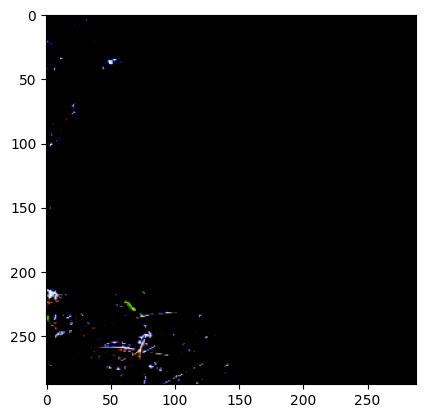

In [21]:
img = train_transform(img0)
plt.imshow(img.permute(1, 2, 0))

In [22]:
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split

img_to_label = {}
for ann in valid_annotations:
    img_id = ann["image_id"]
    if img_id not in img_to_label:
        img_to_label[img_id] = ann["category_id"]

sorted_cat_ids = sorted(target_class_ids)
cat_to_idx     = {cat_id: idx for idx, cat_id in enumerate(sorted_cat_ids)}
num_classes    = len(sorted_cat_ids)
print(f"num_classes: {num_classes}", cat_to_idx)

class OregonDataset(Dataset):
    def __init__(self, images, img_to_label, cat_to_idx, images_dir, transform=None):
        self.samples = [
            (img["file_name"], cat_to_idx[img_to_label[img["id"]]])
            for img in images if img["id"] in img_to_label
        ]
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.images_dir, fname)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

num_classes: 15 {0: 0, 1: 1, 8: 2, 11: 3, 13: 4, 23: 5, 24: 6, 30: 7, 37: 8, 38: 9, 41: 10, 42: 11, 43: 12, 44: 13, 45: 14}


In [23]:
import torch
import torchvision.models as tv_models

device = "cuda" if torch.cuda.is_available() else "cpu"

efficientnet = tv_models.efficientnet_b2(weights=tv_models.EfficientNet_B2_Weights.DEFAULT)
efficientnet = efficientnet.to(device)
total_params = sum(p.numel() for p in efficientnet.parameters())
print(f"EfficientNet-B2 loaded: {total_params:,} params")

EfficientNet-B2 loaded: 9,109,994 params


In [24]:
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from PIL import Image, ImageFile
import os

# Allow PIL to load images that were only partially downloaded
ImageFile.LOAD_TRUNCATED_IMAGES = True

# --- configuration ---
BATCH_SIZE = 64
NUM_WORKERS = 0  # set to 0 if you get a deadlock on Windows+Jupyter
SUBSET_FACTOR = 0.1  # keep only 10% of the full dataset

img_to_label = {}
for ann in valid_annotations:
    img_id = ann["image_id"]
    if img_id not in img_to_label:
        img_to_label[img_id] = ann["category_id"]

sorted_cat_ids = sorted(target_class_ids)
cat_to_idx     = {cat_id: idx for idx, cat_id in enumerate(sorted_cat_ids)}
num_classes    = len(sorted_cat_ids)
print(f"num_classes: {num_classes}", cat_to_idx)

class OregonDataset(Dataset):
    def __init__(self, images, img_to_label, cat_to_idx, images_dir, transform=None):
        self.samples = [
            (img["file_name"], cat_to_idx[img_to_label[img["id"]]])
            for img in images if img["id"] in img_to_label
        ]
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.images_dir, fname)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# Use the torchvision transforms defined earlier
ds_train = OregonDataset(valid_images, img_to_label, cat_to_idx, out_dir, transform=train_transform)
ds_eval  = OregonDataset(valid_images, img_to_label, cat_to_idx, out_dir, transform=val_transform)

labels_all = [s[1] for s in ds_train.samples]
all_indices = list(range(len(ds_train)))

# ------------------------------------------------------------------
# Step 1: take only a stratified subset of the whole dataset
# ------------------------------------------------------------------
subset_indices, _ = train_test_split(
    all_indices,
    train_size=SUBSET_FACTOR,
    stratify=labels_all,
    random_state=42
)

subset_labels = [labels_all[i] for i in subset_indices]

# ------------------------------------------------------------------
# Step 2: split that subset into 80/10/10, still stratified
# ------------------------------------------------------------------
train_idx, temp_idx = train_test_split(
    subset_indices,
    test_size=0.2,  # 20% of subset goes to val+test
    stratify=subset_labels,
    random_state=42
)

temp_labels = [labels_all[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,  # split remaining 20% into 10% val / 10% test
    stratify=temp_labels,
    random_state=42
)

train_set = Subset(ds_train, train_idx)
val_set   = Subset(ds_eval,  val_idx)
test_set  = Subset(ds_eval,  test_idx)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    persistent_workers=False
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    persistent_workers=False
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    persistent_workers=False
)

print(f"Original dataset: {len(ds_train)}")
print(f"Subset used ({SUBSET_FACTOR*100:.0f}%): {len(subset_indices)}")
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Batch size: {BATCH_SIZE} | Workers: {NUM_WORKERS}")

num_classes: 15 {0: 0, 1: 1, 8: 2, 11: 3, 13: 4, 23: 5, 24: 6, 30: 7, 37: 8, 38: 9, 41: 10, 42: 11, 43: 12, 44: 13, 45: 14}
Original dataset: 27371
Subset used (10%): 2737
Train: 2189 | Val: 274 | Test: 274
Batch size: 64 | Workers: 0


## Training

In [25]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [26]:
from tqdm.auto import tqdm

def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None, patience=3):
    res = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    total_batches = len(_train_loader) + len(_val_loader)
    best_val_loss = float('inf')
    best_weights = None
    no_improve = 0

    overall_pbar = tqdm(total=_num_epochs, desc="Training", unit="epoch", leave=True)
    tqdm.write("")

    for epoch in range(_num_epochs):
        _model.train()
        train_loss = 0.0
        train_acc  = 0.0

        with tqdm(total=total_batches, desc=f"Epoch {epoch+1}/{_num_epochs}", unit="batch", leave=True) as pbar:
            for X_batch, y_batch in _train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                _optimizer.zero_grad()
                _x = X_batch
                if _transforms is not None:
                    _x = _transforms(_x)
                outputs = _model(_x)
                loss = _criterion(outputs, y_batch)
                loss.backward()
                _optimizer.step()
                train_loss += loss.item() * X_batch.size(0)
                train_acc  += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))
                pbar.update(1)

            epoch_train_loss = train_loss / len(_train_loader.dataset)

            _model.eval()
            val_loss = 0.0
            val_acc  = 0.0
            with torch.no_grad():
                for X_val, y_val in _val_loader:
                    X_val, y_val = X_val.to(device), y_val.to(device)
                    val_outputs = _model(X_val)
                    val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                    val_acc  += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))
                    pbar.update(1)

            epoch_val_loss = val_loss / len(_val_loader.dataset)
            pbar.set_postfix(
                train_loss=f"{epoch_train_loss:.4f}",
                train_acc=f"{train_acc:.4f}",
                val_loss=f"{epoch_val_loss:.4f}",
                val_acc=f"{val_acc:.4f}"
            )

        overall_pbar.update(1)
        overall_pbar.set_postfix(train_loss=f"{epoch_train_loss:.4f}", val_acc=f"{val_acc:.4f}")

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_weights = copy.deepcopy(_model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                tqdm.write(f"Early stopping at epoch {epoch+1}")
                overall_pbar.close()
                break

    overall_pbar.close()

    if best_weights is not None:
        _model.load_state_dict(best_weights)

    tqdm.write(f"Final - train_loss: {res['train_loss'][-1]:.4f}  train_acc: {res['train_acc'][-1]:.4f}  "
               f"val_loss: {res['val_loss'][-1]:.4f}  val_acc: {res['val_acc'][-1]:.4f}")

    return res

In [27]:
def plot_learning_curves(res, title):
    epochs = range(1, len(res['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, res['train_loss'], label='Train')
    ax1.plot(epochs, res['val_loss'],   label='Validation')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, res['train_acc'], label='Train')
    ax2.plot(epochs, res['val_acc'],   label='Validation')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [28]:
def measure_overfitting(res):
    loss_gap = res['val_loss'][-1] - res['train_loss'][-1]
    acc_gap  = res['train_acc'][-1] - res['val_acc'][-1]
    print(f"Overfitting - loss gap (val-train): {loss_gap:.4f} | accuracy gap (train-val): {acc_gap:.4f}")
    if acc_gap > 0.1 or loss_gap > 0.5:
        print("  â†’ Significant overfitting detected.")
    else:
        print("  â†’ No significant overfitting.")
    return loss_gap, acc_gap

### Model

The chosen pre-trained model is [EfficientNet-B2](https://pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b2.html), pretrained on ImageNet-1k. It is ~9.1M parameters and uses a compound-scaling strategy (depth + width + resolution) that achieves strong accuracy at modest compute cost, making it well-suited for wildlife animal recognition.

In [29]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
from PIL import Image
import copy

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = tv_models.efficientnet_b2(weights=tv_models.EfficientNet_B2_Weights.DEFAULT)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"EfficientNet-B2 â€” {total_params:,} params | device: {device}")

EfficientNet-B2 â€” 9,109,994 params | device: cpu


### Architecture 1

In [32]:
arch1 = copy.deepcopy(model)

In [33]:
in_features = arch1.classifier[1].in_features   # 1408 for EfficientNet-B2
arch1.classifier[1] = nn.Linear(in_features, num_classes)
arch1 = arch1.to(device)
print(f"Classifier head replaced: Linear({in_features}, {num_classes})")

Classifier head replaced: Linear(1408, 15)


#### Transfer Learning

In [34]:
for param in arch1.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in arch1.parameters() if p.requires_grad)
total = sum(p.numel() for p in arch1.parameters())
print(f"Trainable: {trainable:,} / {total:,}  (classifier head only)")

Trainable: 21,135 / 7,722,129  (classifier head only)


In [35]:
optimizer_tl = torch.optim.Adam(arch1.classifier.parameters(), lr=1e-3)
criterion    = nn.CrossEntropyLoss()

In [36]:
res = train(arch1, train_loader, val_loader, criterion, optimizer_tl, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Final - train_loss: 1.1831  train_acc: 0.6313  val_loss: 1.0920  val_acc: 0.7044


In [37]:
res_arch1_tl = res
torch.save(arch1.state_dict(), 'arch1_tl.pth')

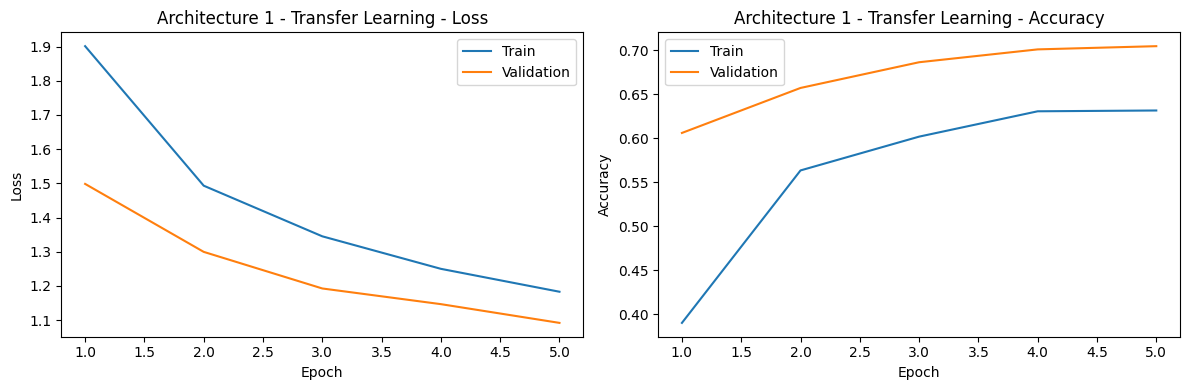

In [38]:
plot_learning_curves(res_arch1_tl, 'Architecture 1 - Transfer Learning')

#### Fine Tuning

In [39]:
arch1.load_state_dict(torch.load('arch1_tl.pth', map_location=device))

# Freeze everything first
for param in arch1.parameters():
    param.requires_grad = False

# Unfreeze last 2 feature blocks (7 and 8) + the classifier head
NUM_UNFREEZE = 2
for block in list(arch1.features.children())[-NUM_UNFREEZE:]:
    for param in block.parameters():
        param.requires_grad = True

for param in arch1.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in arch1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in arch1.parameters())
print(f"Trainable: {trainable:,} / {total:,}  (last {NUM_UNFREEZE} feature blocks + classifier)")

Trainable: 3,255,387 / 7,722,129  (last 2 feature blocks + classifier)


In [40]:
unfrozen_blocks = list(arch1.features.children())[-NUM_UNFREEZE:]

ft_params = [
    {"params": [p for b in unfrozen_blocks for p in b.parameters()], "lr": 1e-5},
    {"params": list(arch1.classifier.parameters()),                   "lr": 1e-3},
]

ft_optimizer = torch.optim.Adam(ft_params)

In [41]:
res_arch1_ft = train(arch1, train_loader, val_loader, criterion, ft_optimizer, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Final - train_loss: 0.9445  train_acc: 0.7012  val_loss: 0.9165  val_acc: 0.7226


In [42]:
torch.save(arch1.state_dict(), 'arch1_ft.pth')

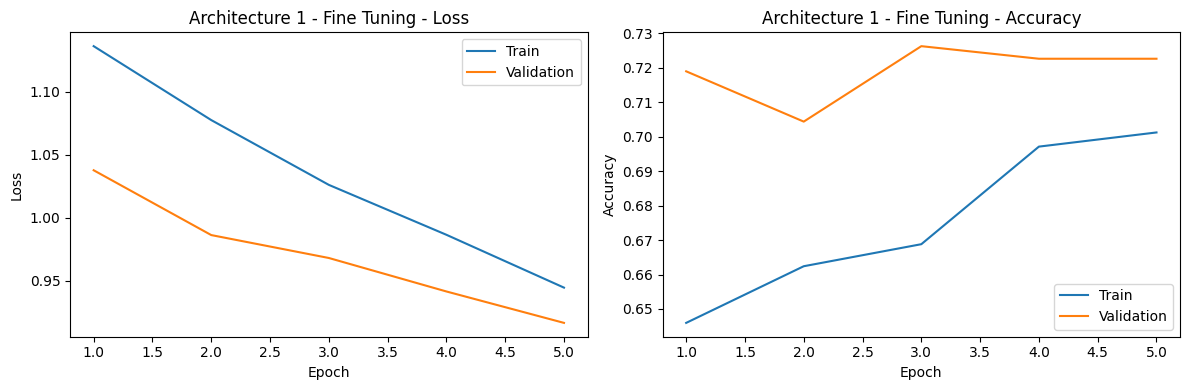

In [43]:
plot_learning_curves(res_arch1_ft, 'Architecture 1 - Fine Tuning')

### Architecture 2

The chosen pre-trained model is [MobileNetV3-Small](https://pytorch.org/vision/stable/models/generated/torchvision.models.mobilenet_v3_small.html), pretrained on ImageNet-1k. It is ~2.5M parameters and uses depthwise separable convolutions with a squeeze-and-excitation mechanism, designed specifically for CPU/mobile inference. Input resolution is reduced to 160Ã—160 (vs. 288Ã—288 for Architecture 1), cutting forward-pass cost by ~3Ã— while reusing the same dataset split. TL trains only the built-in 3-layer classifier (the hidden linear layer is pretrained capacity, only the output layer is swapped); FT unfreezes solely the last InvertedResidual block and uses a single uniform learning rate, deliberately simpler than Architecture 1's differential scheme.

In [44]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

train_transform_160 = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((0, 0, img.width, int(img.height * 0.94)))),
    transforms.Resize(192),
    transforms.RandomCrop(160),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform_160 = transforms.Compose([
    transforms.Lambda(lambda img: img.crop((0, 0, img.width, int(img.height * 0.94)))),
    transforms.Resize(192),
    transforms.CenterCrop(160),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

ds_train_160 = OregonDataset(valid_images, img_to_label, cat_to_idx, out_dir, transform=train_transform_160)
ds_eval_160  = OregonDataset(valid_images, img_to_label, cat_to_idx, out_dir, transform=val_transform_160)

train_set_160 = Subset(ds_train_160, train_idx)
val_set_160   = Subset(ds_eval_160,  val_idx)
test_set_160  = Subset(ds_eval_160,  test_idx)

train_loader_160 = DataLoader(train_set_160, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, persistent_workers=False)
val_loader_160   = DataLoader(val_set_160,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=False)
test_loader_160  = DataLoader(test_set_160,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, persistent_workers=False)

print(f"160Ã—160 loaders â€” Train: {len(train_set_160)} | Val: {len(val_set_160)} | Test: {len(test_set_160)}")

160Ã—160 loaders â€” Train: 2189 | Val: 274 | Test: 274


In [45]:
mobilenet = tv_models.mobilenet_v3_small(weights=tv_models.MobileNet_V3_Small_Weights.DEFAULT)
mobilenet  = mobilenet.to(device)

total_params = sum(p.numel() for p in mobilenet.parameters())
print(f"MobileNetV3-Small loaded: {total_params:,} params | device: {device}")

arch2 = copy.deepcopy(mobilenet)

# MobileNetV3-Small classifier: Linear(576,1024) â†’ Hardswish â†’ Dropout â†’ Linear(1024,1000)
# Replace only the final output layer
in_features_2 = arch2.classifier[3].in_features  # 1024
arch2.classifier[3] = nn.Linear(in_features_2, num_classes)
arch2 = arch2.to(device)
print(f"Classifier head replaced: Linear({in_features_2}, {num_classes})")

MobileNetV3-Small loaded: 2,542,856 params | device: cpu
Classifier head replaced: Linear(1024, 15)


#### Transfer Learning

In [46]:
for param in arch2.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in arch2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in arch2.parameters())
print(f"Trainable: {trainable:,} / {total:,}  (classifier only)")

Trainable: 606,223 / 1,533,231  (classifier only)


In [47]:
optimizer_tl_2 = torch.optim.Adam(arch2.classifier.parameters(), lr=1e-3)

In [48]:
res = train(arch2, train_loader_160, val_loader_160, criterion, optimizer_tl_2, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Final - train_loss: 1.0723  train_acc: 0.6263  val_loss: 1.0602  val_acc: 0.6606


In [49]:
res_arch2_tl = res
torch.save(arch2.state_dict(), 'arch2_tl.pth')

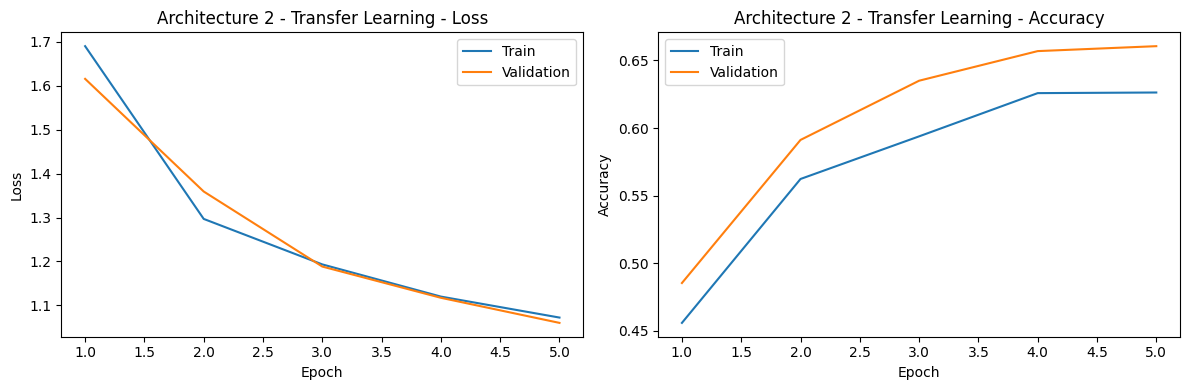

In [50]:
plot_learning_curves(res_arch2_tl, 'Architecture 2 - Transfer Learning')

#### Fine Tuning

In [51]:
arch2.load_state_dict(torch.load('arch2_tl.pth', map_location=device))

# Freeze everything
for param in arch2.parameters():
    param.requires_grad = False

# Unfreeze only the last InvertedResidual block + classifier
for param in arch2.features[-1].parameters():
    param.requires_grad = True
for param in arch2.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in arch2.parameters() if p.requires_grad)
total     = sum(p.numel() for p in arch2.parameters())
print(f"Trainable: {trainable:,} / {total:,}  (last feature block + classifier)")

Trainable: 662,671 / 1,533,231  (last feature block + classifier)


In [52]:
optimizer_ft_2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, arch2.parameters()),
    lr=1e-4
)

In [53]:
res_arch2_ft = train(arch2, train_loader_160, val_loader_160, criterion, optimizer_ft_2, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Final - train_loss: 0.9495  train_acc: 0.6583  val_loss: 0.9367  val_acc: 0.7007


In [54]:
torch.save(arch2.state_dict(), 'arch2_ft.pth')

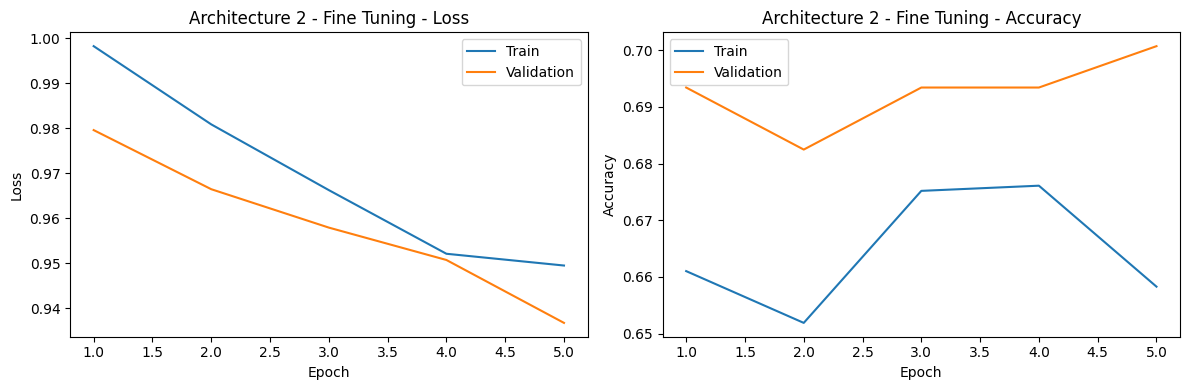

In [55]:
plot_learning_curves(res_arch2_ft, 'Architecture 2 - Fine Tuning')

### Architecture 3

The chosen pre-trained model is [EfficientNet-B0](https://pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b0.html), pretrained on ImageNet-1k. It is ~5.3M parameters â€” the smallest member of the EfficientNet family â€” run at 160Ã—160 input. TL replaces the default single-Linear classifier with a **2-layer MLP** (Linear(1280, 128) â†’ ReLU â†’ Dropout â†’ Linear(128, 15)), giving the head more capacity to adapt to the wildlife domain. FT uses **gradual unfreezing**: backbone blocks are thawed one at a time (last to first, 2 epochs per stage) with differential learning rates, reducing the risk of destabilizing early general-purpose features before the head has converged.

In [56]:
b0_model = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.DEFAULT)
b0_model = b0_model.to(device)

total_params = sum(p.numel() for p in b0_model.parameters())
print(f"EfficientNet-B0 loaded: {total_params:,} params | device: {device}")

arch3 = copy.deepcopy(b0_model)

in_features_3 = arch3.classifier[1].in_features  # 1280
arch3.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features_3, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, num_classes),
)
arch3 = arch3.to(device)
print(f"2-layer MLP head: Linear({in_features_3}, 128) â†’ ReLU â†’ Dropout â†’ Linear(128, {num_classes})")

EfficientNet-B0 loaded: 5,288,548 params | device: cpu
2-layer MLP head: Linear(1280, 128) â†’ ReLU â†’ Dropout â†’ Linear(128, 15)


#### Transfer Learning

In [57]:
for param in arch3.features.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in arch3.parameters() if p.requires_grad)
total     = sum(p.numel() for p in arch3.parameters())
print(f"Trainable: {trainable:,} / {total:,}  (2-layer MLP head only)")

Trainable: 165,903 / 4,173,451  (2-layer MLP head only)


In [58]:
optimizer_tl_3 = torch.optim.Adam(arch3.classifier.parameters(), lr=1e-3)

In [59]:
res = train(arch3, train_loader_160, val_loader_160, criterion, optimizer_tl_3, _num_epochs=5)

Training:   0%|          | 0/5 [00:00<?, ?epoch/s]

Epoch 1/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 2/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 3/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 4/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 5/5:   0%|          | 0/40 [00:00<?, ?batch/s]

Final - train_loss: 1.2061  train_acc: 0.6117  val_loss: 1.0473  val_acc: 0.6569


In [60]:
res_arch3_tl = res
torch.save(arch3.state_dict(), 'arch3_tl.pth')

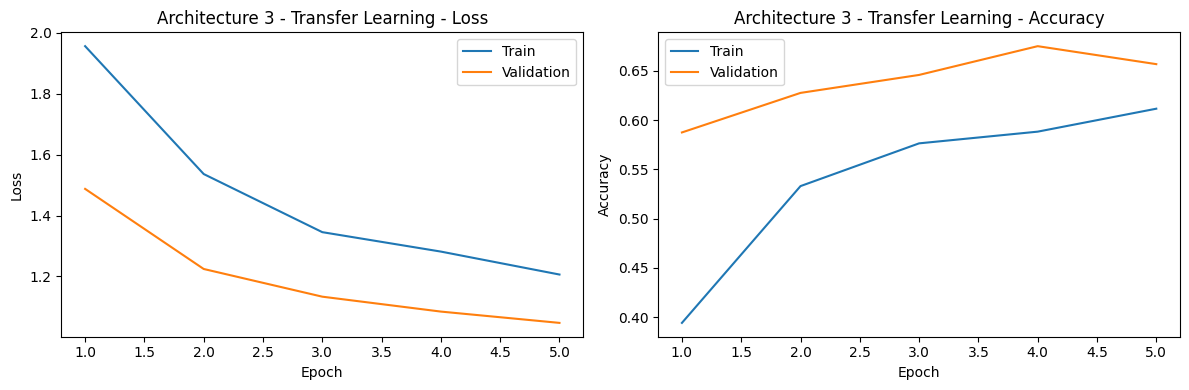

In [61]:
plot_learning_curves(res_arch3_tl, 'Architecture 3 - Transfer Learning')

#### Fine Tuning

In [66]:
arch3.load_state_dict(torch.load('arch3_tl.pth', map_location=device))

# Start with everything frozen except the classifier head
for param in arch3.parameters():
    param.requires_grad = False
for param in arch3.classifier.parameters():
    param.requires_grad = True

feature_blocks  = list(arch3.features.children())
res_arch3_ft    = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Unfreeze 1 more block per stage (last â†’ first), 2 epochs each
for stage in range(1, 4):
    for param in feature_blocks[-stage].parameters():
        param.requires_grad = True

    trainable = sum(p.numel() for p in arch3.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in arch3.parameters())
    print(f"\nStage {stage} - unfreeze block -{stage}: {trainable:,} / {total:,} trainable")

    unfrozen_backbone = [p for p in arch3.features.parameters() if p.requires_grad]
    ft_opt_3 = torch.optim.Adam([
        {"params": unfrozen_backbone,                    "lr": 1e-5},
        {"params": list(arch3.classifier.parameters()),  "lr": 1e-3},
    ])

    res = train(arch3, train_loader_160, val_loader_160, criterion, ft_opt_3, _num_epochs=2)
    for k in res_arch3_ft:
        res_arch3_ft[k].extend(res[k])


Stage 1 - unfreeze block -1: 578,063 / 4,173,451 trainable


Training:   0%|          | 0/2 [00:00<?, ?epoch/s]

Epoch 1/2:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 2/2:   0%|          | 0/40 [00:00<?, ?batch/s]

Final - train_loss: 1.1366  train_acc: 0.6263  val_loss: 0.9817  val_acc: 0.6898

Stage 2 - unfreeze block -2: 1,295,295 / 4,173,451 trainable


...

Final - train_loss: 1.0692  train_acc: 0.6505  val_loss: 0.9382  val_acc: 0.6898

Stage 3 - unfreeze block -3: 3,321,643 / 4,173,451 trainable


Training:   0%|          | 0/2 [00:00<?, ?epoch/s]

Epoch 1/2:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 2/2:   0%|          | 0/40 [00:00<?, ?batch/s]

Final - train_loss: 1.0177  train_acc: 0.6510  val_loss: 0.9713  val_acc: 0.7117


In [67]:
torch.save(arch3.state_dict(), 'arch3_ft.pth')

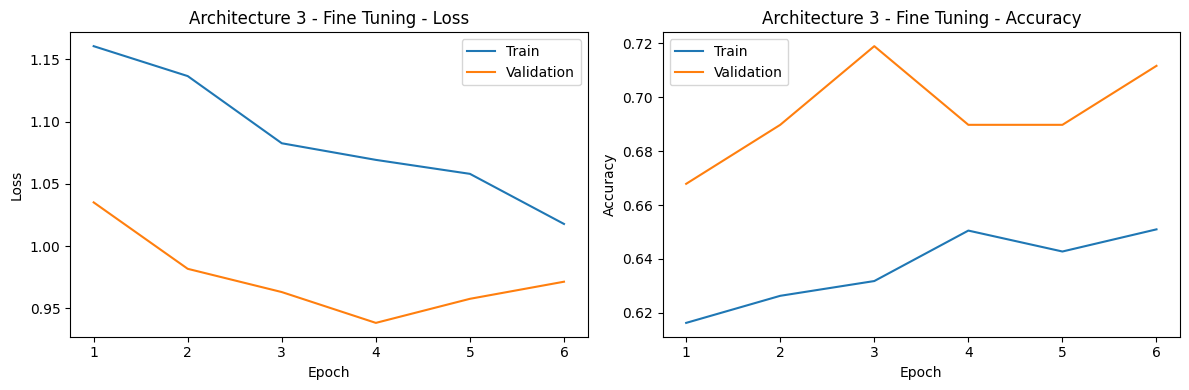

In [68]:
plot_learning_curves(res_arch3_ft, 'Architecture 3 - Fine Tuning')

## Evaluation

In [69]:
candidates = {
    "arch1_ft": {"val_acc": res_arch1_ft["val_acc"][-1], "train_acc": res_arch1_ft["train_acc"][-1],
                 "val_loss": res_arch1_ft["val_loss"][-1], "train_loss": res_arch1_ft["train_loss"][-1],
                 "model": arch1, "loader": test_loader, "res": res_arch1_ft},
    "arch2_ft": {"val_acc": res_arch2_ft["val_acc"][-1], "train_acc": res_arch2_ft["train_acc"][-1],
                 "val_loss": res_arch2_ft["val_loss"][-1], "train_loss": res_arch2_ft["train_loss"][-1],
                 "model": arch2, "loader": test_loader_160, "res": res_arch2_ft},
    "arch3_ft": {"val_acc": res_arch3_ft["val_acc"][-1], "train_acc": res_arch3_ft["train_acc"][-1],
                 "val_loss": res_arch3_ft["val_loss"][-1], "train_loss": res_arch3_ft["train_loss"][-1],
                 "model": arch3, "loader": test_loader_160, "res": res_arch3_ft},
}

OVERFIT_PENALTY = 0.5
for k, v in candidates.items():
    overfit_gap = max(0.0, v["train_acc"] - v["val_acc"])
    v["score"] = v["val_acc"] - OVERFIT_PENALTY * overfit_gap
    print(f"{k}: val_acc={v["val_acc"]:.4f}  train_acc={v["train_acc"]:.4f}"
          f"  gap={overfit_gap:.4f}  score={v["score"]:.4f}")

best_key = max(candidates, key=lambda k: candidates[k]["score"])
best_entry = candidates[best_key]
print(f"\nSelected: {best_key} (score={best_entry["score"]:.4f})")

arch1_ft: val_acc=0.7226  train_acc=0.7012  gap=0.0000  score=0.7226
arch2_ft: val_acc=0.7007  train_acc=0.6583  gap=0.0000  score=0.7007
arch3_ft: val_acc=0.7117  train_acc=0.6510  gap=0.0000  score=0.7117

Selected: arch1_ft (score=0.7226)


In [74]:
import torch
import numpy as np

best_model = best_entry["model"]
best_loader = best_entry["loader"]
best_model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for X, y in best_loader:
        X = X.to(device)
        logits = best_model(X)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(y.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.vstack(all_probs)

In [75]:
from sklearn.metrics import accuracy_score, classification_report

idx_to_cat = {v: k for k, v in cat_to_idx.items()}
class_names = [cat_ids[idx_to_cat[i]] for i in range(num_classes)]

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names, labels=range(num_classes)))

Test Accuracy: 0.7226

                            precision    recall  f1-score   support

                     empty       0.77      0.72      0.74        88
                    coyote       0.00      0.00      0.00         1
      reptile or amphibian       1.00      0.67      0.80         3
california ground squirrel       0.00      0.00      0.00         1
     western spotted skunk       0.86      0.55      0.67        22
            american robin       0.50      0.44      0.47        16
          leporidae family       0.74      0.82      0.78        62
              invertebrate       1.00      0.75      0.86         4
          northern raccoon       0.33      0.50      0.40         4
             striped skunk       0.00      0.00      0.00         2
              domestic dog       0.00      0.00      0.00         1
                     human       0.00      0.00      0.00         0
              small mammal       0.71      0.89      0.79        53
                  gray f

c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capit

In [76]:
train_acc_final = best_entry["res"]["train_acc"][-1]
train_loss_final = best_entry["res"]["train_loss"][-1]
val_acc_final = best_entry["val_acc"]
print(f"Train acc : {train_acc_final:.4f}")
print(f"Val   acc : {val_acc_final:.4f}")
print(f"Test  acc : {test_acc:.4f}")
print(f"Train-Test gap: {train_acc_final - test_acc:.4f}")
if train_acc_final - test_acc > 0.1:
    print("-> Significant overfitting detected. Consider next best model.")
else:
    print("-> No significant overfitting detected.")

Train acc : 0.7012
Val   acc : 0.7226
Test  acc : 0.7226
Train-Test gap: -0.0214
-> No significant overfitting detected.


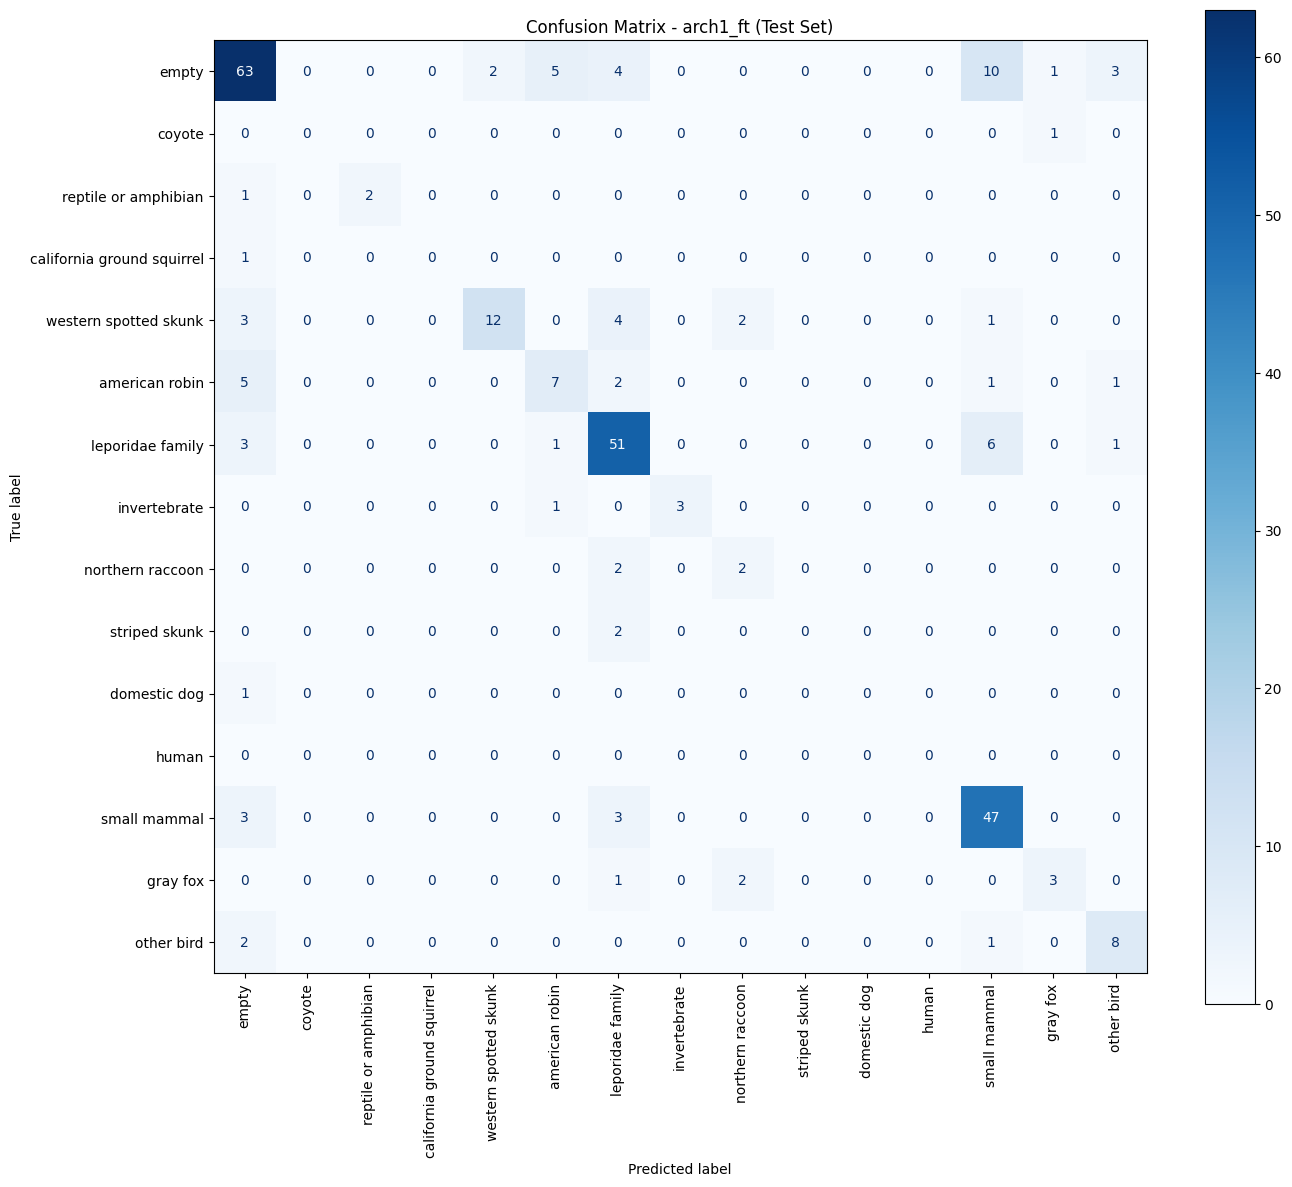

In [78]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds, labels=range(num_classes))
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=True, cmap="Blues")
ax.set_title(f"Confusion Matrix - {best_key} (Test Set)")
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_11448\464298547.py:1: RuntimeWarning: invalid value encountered in divide
  per_class_acc = cm.diagonal() / cm.sum(axis=1)


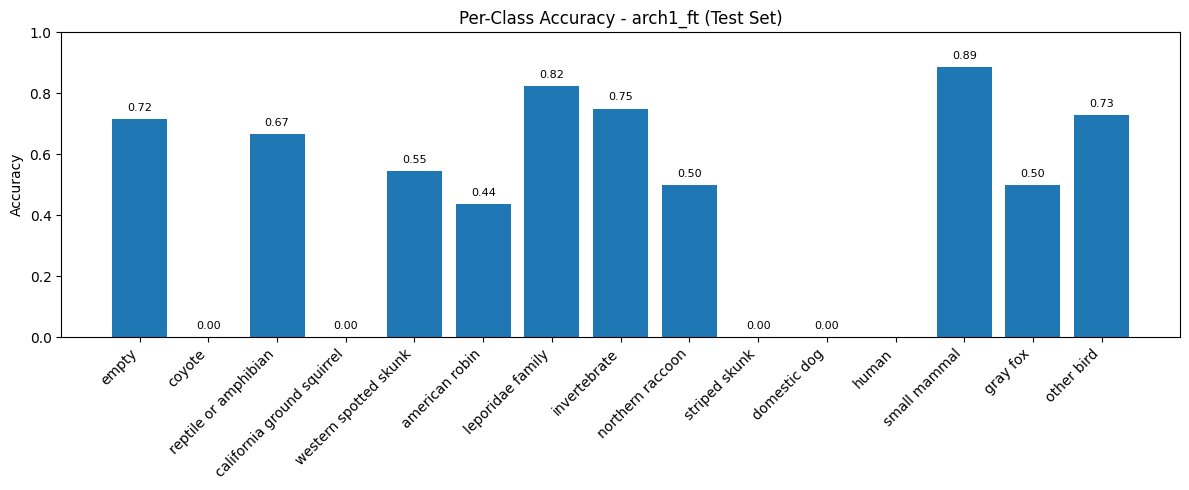

In [79]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_names, per_class_acc)
ax.set_ylim(0, 1)
ax.set_ylabel("Accuracy")
ax.set_title(f"Per-Class Accuracy - {best_key} (Test Set)")
plt.xticks(rotation=45, ha="right")
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


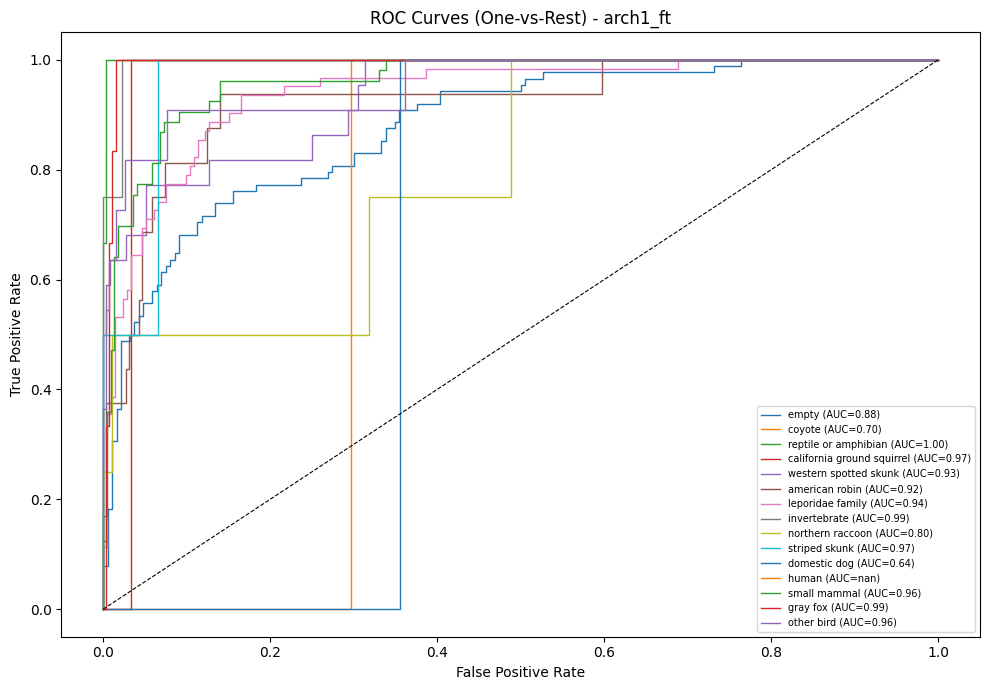

In [80]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(all_labels, classes=list(range(num_classes)))
fig, ax = plt.subplots(figsize=(10, 7))
for i, name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=1, label=f"{name} (AUC={auc(fpr, tpr):.2f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curves (One-vs-Rest) - {best_key}")
ax.legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()

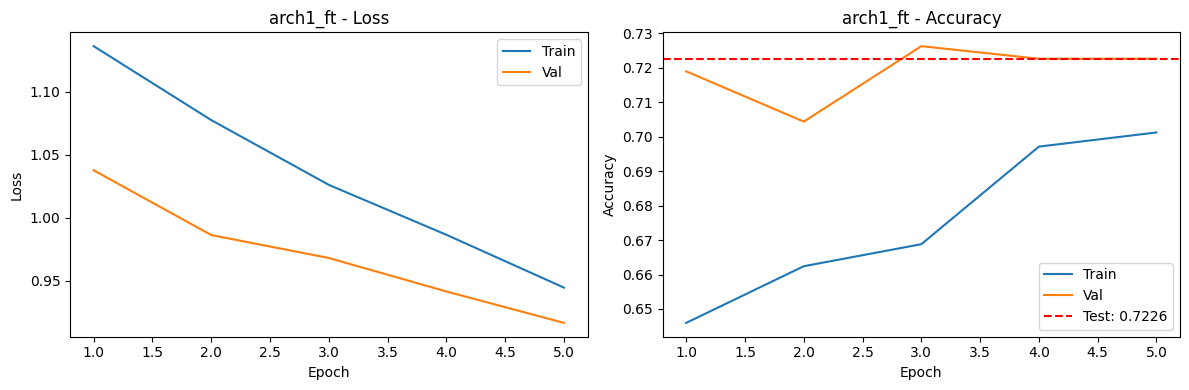

In [81]:
res_best = best_entry["res"]
epochs = range(1, len(res_best["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, res_best["train_loss"], label="Train")
ax1.plot(epochs, res_best["val_loss"],   label="Val")
ax1.set_title(f"{best_key} - Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend()

ax2.plot(epochs, res_best["train_acc"], label="Train")
ax2.plot(epochs, res_best["val_acc"],   label="Val")
ax2.axhline(y=test_acc, color="red", linestyle="--", label=f"Test: {test_acc:.4f}")
ax2.set_title(f"{best_key} - Accuracy")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.legend()

plt.tight_layout()
plt.show()

In [83]:
import torch.onnx

best_model.eval()
sample_batch, _ = next(iter(best_loader))
dummy = sample_batch[:1].to(device)

onnx_path = f"{best_key}.onnx"
torch.onnx.export(
    best_model, dummy, onnx_path,
    input_names=["input"], output_names=["logits"],
    dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=17,
)
print(f"Exported to {onnx_path}")

C:\Users\PC\AppData\Local\Temp\ipykernel_11448\3574903839.py:8: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0423 00:27:29.691000 11448 site-packages\torch\onnx\_internal\exporter\_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Translate the graph into ONNX... ✅


Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\onnxscript\version_converter\_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\onnxscript\version_converter\__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PC\Desktop\cetys-icc-compint\.conda\Lib\site-packages\onnx\version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, t

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported to arch1_ft.onnx


In [84]:
import onnxruntime as ort

sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
ort_out = sess.run(["logits"], {"input": dummy.numpy()})[0]

with torch.no_grad():
    pt_out = best_model(dummy).numpy()

max_diff = abs(ort_out - pt_out).max()
print(f"Max output diff (PyTorch vs ONNX): {max_diff:.2e}")
print("ONNX export validated." if max_diff < 1e-4 else "WARNING: outputs differ.")

Max output diff (PyTorch vs ONNX): 7.63e-06
ONNX export validated.


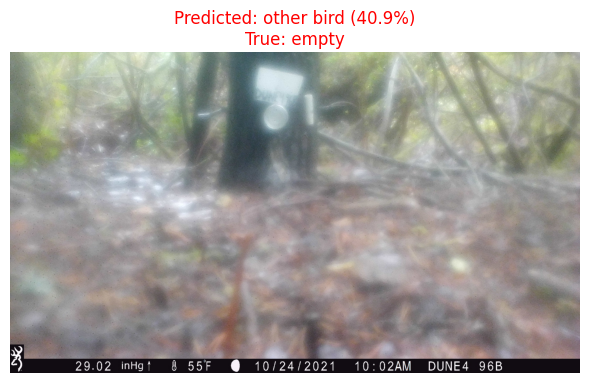

In [115]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch
import numpy as np

# Pick a random image from the test set
random_idx = random.randint(0, len(test_set) - 1)
img_tensor, true_label = test_set[random_idx]

# Run inference through the ONNX session
input_arr = img_tensor.unsqueeze(0).numpy()
logits = sess.run(["logits"], {"input": input_arr})[0]
pred_label = int(np.argmax(logits))
confidence = float(torch.softmax(torch.tensor(logits), dim=1).max())

# Display the image with prediction
fname, _ = test_set.dataset.samples[test_set.indices[random_idx]]
img = Image.open(f"{out_dir}/{fname}").convert("RGB")

plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Predicted: {class_names[pred_label]} ({confidence:.1%})\n"
    f"True: {class_names[true_label]}",
    color="green" if pred_label == true_label else "red"
)
plt.tight_layout()
plt.show()